In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xraydb
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer, epix_camera


### calculate basic model spectrum

In [19]:
v = np.linspace(-3,3,1000)    


#SOURCE
sourceFe = CobaltFe ()
sourceFe.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
sourceFe.Gamma_ev = 6.75e-9 * 1.096 #natural linewidth broadened by 9.6% for cosine braodening
sourceFe.update_params()


#ABSORBER A1
absorberAX = alphaFe()
absorberAX.thickness_m = 200e-9
absorberAX.abundance = 0.96
absorberAX.Eres = [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13] #from pipcorn
absorberAX.update_params()


#DETECTOR
detector = epix_camera()
detector.distance_sd = 32.6e-3
detector.distance_sa = 21.8e-3
detector.source_radius = 3e-3
detector.absorber_radius = 25.4e-3
detector.efficiency_14keV = 0.9
detector.snr14keV = 7
detector.quartz_thickness_m = 200e-6
detector.update_params()

moss = Mossbauer(sourceFe, absorberAX, detector)

total_spectrum = moss.total_spectrum(v)
ideal_spectrum = moss.total_transmission_rate(v)
resonant_transmission_rate = moss.resonant_transmission_rate(v)
nonresonant_transmission_rate = moss.nonresonant_transmission_rate()
reemission_rate = moss.reemission_rate(v)*10
compton_offset = moss.compton_offset()




ideal visibility: 0.1616777859454217
expected visibility: 0.13874204931877257


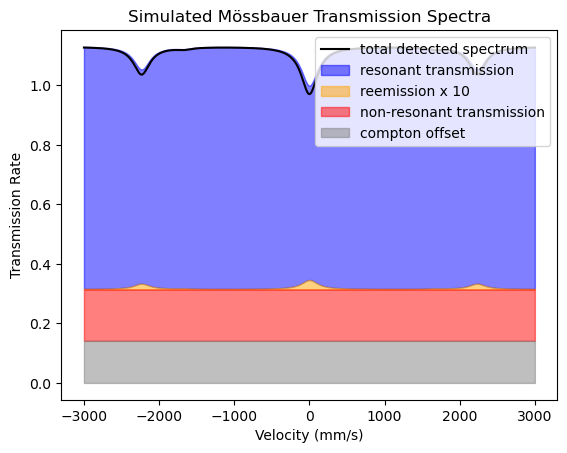

In [20]:
plt.plot(v*1e3, total_spectrum, color = 'black', label='total detected spectrum')
plt.fill_between(v*1e3,compton_offset+reemission_rate+nonresonant_transmission_rate,compton_offset+reemission_rate+nonresonant_transmission_rate + resonant_transmission_rate, color = 'blue',alpha = 0.5, label='resonant transmission')
plt.fill_between(v*1e3,compton_offset+nonresonant_transmission_rate,compton_offset+nonresonant_transmission_rate +reemission_rate, color = 'orange',alpha = 0.5, label='reemission x 10')
plt.fill_between(v*1e3,compton_offset,compton_offset+nonresonant_transmission_rate, color = 'red',alpha = 0.5, label='non-resonant transmission')
plt.fill_between(v*1e3,0,compton_offset, color = 'gray',alpha = 0.5, label='compton offset')
plt.xlabel('Velocity (mm/s)')
plt.xlabel('Velocity (mm/s)')
plt.ylabel('Transmission Rate')
#plt.ylim(0,1)
plt.legend(loc = 'upper right')
plt.title('Simulated Mössbauer Transmission Spectra')

print("ideal visibility:", (ideal_spectrum.max()-ideal_spectrum.min())/ideal_spectrum.max())
print("expected visibility:", (total_spectrum.max()-total_spectrum.min())/total_spectrum.max())


### SDD detector
 - alphaFe20mum: source-5cm-absorber-0.5cm-detector

Measured visibility: 0.204
Theoretical max visibility: 0.297
Theoretical visibility with SNR=7: 0.275
Actual visibility from reemitted: 0.204
Solid angle ratio: 76.174
Absorber relative solid angle: 0.105
Reemitted detected fraction: 0.032


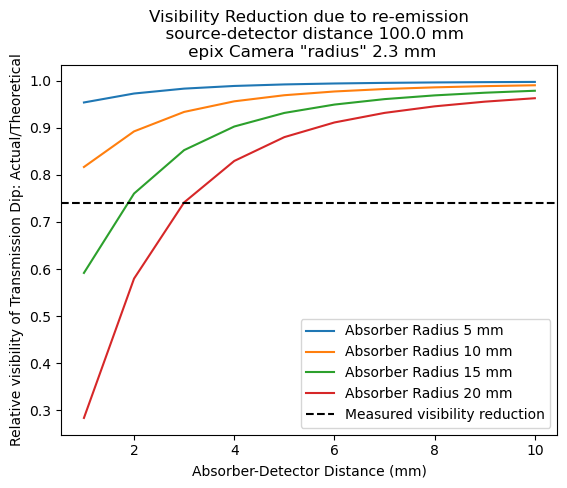

In [ ]:
t = t_AX
moss = moss_AX
absorber = absorberAX
source = sourceFe

visibility_theory_max = (t.max()-t.min())/t.max()

SNR = 7
vis_reduction = 1-0.5/(SNR)
visibility_theory = (t.max()-t.min())/t.max()*vis_reduction

d_sd = 100e-3
d_sa = 97e-3
d_ad = d_sd - d_sa
r_a = 20e-3
r_d = np.sqrt(17e-6/np.pi)

def compute_solid_angle(r, d):
    return 2*np.pi*(1-d/np.sqrt(r**2 + d**2))

s_d_solid_angle = compute_solid_angle(r_d, d_sd)
s_a_solid_angle = compute_solid_angle(r_a, d_sa)
a_d_solid_angle = compute_solid_angle(r_d, d_ad)
solid_angle_ratio =  s_a_solid_angle/s_d_solid_angle
reemitted_fraction = visibility_theory_max*1/(absorber.alpha+1)
visibility_actual_from_reemitted = visibility_theory*(1-reemitted_fraction*solid_angle_ratio*a_d_solid_angle/(4*np.pi)
)

print(f"Measured visibility: {visibility_meas:.3f}")
print(f"Theoretical max visibility: {visibility_theory_max:.3f}")
print(f"Theoretical visibility with SNR={SNR}: {visibility_theory:.3f}")
print(f"Actual visibility from reemitted: {visibility_actual_from_reemitted:.3f}")
print(f"Solid angle ratio: {solid_angle_ratio:.3f}")
print(f"Absorber relative solid angle: {a_d_solid_angle/(4*np.pi):.3f}")
print(f"Reemitted detected fraction: {reemitted_fraction:.3f}")


vlist = []
dlist = np.linspace(1e-3,10e-3,10)
ralist = [5e-3,10e-3,15e-3,20e-3]

for r_a in ralist:
    vlist = []

    for d_ad in dlist:
        d_sd = 100e-3
        d_sa = d_sd - d_ad
        #r_a = 20e-3
        r_d = np.sqrt(17e-6/np.pi)


        s_d_solid_angle = compute_solid_angle(r_d, d_sd)
        s_a_solid_angle = compute_solid_angle(r_a, d_sa)
        a_d_solid_angle = compute_solid_angle(r_d, d_ad)
        solid_angle_ratio =  s_a_solid_angle/s_d_solid_angle
        reemitted_fraction = visibility_theory_max*1/(absorber.alpha+1)
        visibility_actual_from_reemitted = visibility_theory*(1-reemitted_fraction*solid_angle_ratio*a_d_solid_angle/(4*np.pi)
        )

        vlist.append(visibility_actual_from_reemitted)
    plt.plot(dlist*1e3, np.array(vlist)/visibility_theory, label=f'Absorber Radius {r_a*1e3:.0f} mm')
    #plt.axvline(3, color='k', linestyle='--')
plt.axhline (visibility_meas/visibility_theory, color='k', linestyle='--', label='Measured visibility reduction')
plt.xlabel('Absorber-Detector Distance (mm)')
plt.ylabel('Relative visibility of Transmission Dip: Actual/Theoretical')
plt.title(f'Visibility Reduction due to re-emission\n  source-detector distance {d_sd*1e3:.1f} mm\n epix Camera "radius" {r_d*1e3:.1f} mm')
plt.legend()    



### Iron analytics detector
 - alphaFe25mum: source-10cm-absorber-10cm-detector
 - A1,A2: source-18cm-absorber-200mumquartz-1cm-detector

### SLAC camera
- A2: source-22mm-quartz200mu-absorber-10mm-camera

Measured visibility: 0.058
Theoretical max visibility: 0.171
Theoretical visibility with SNR=1: 0.085
Actual visibility from reemitted: 0.084
Solid angle ratio: 2.816
Absorber relative solid angle: 0.252
Reemitted detected fraction: 0.019


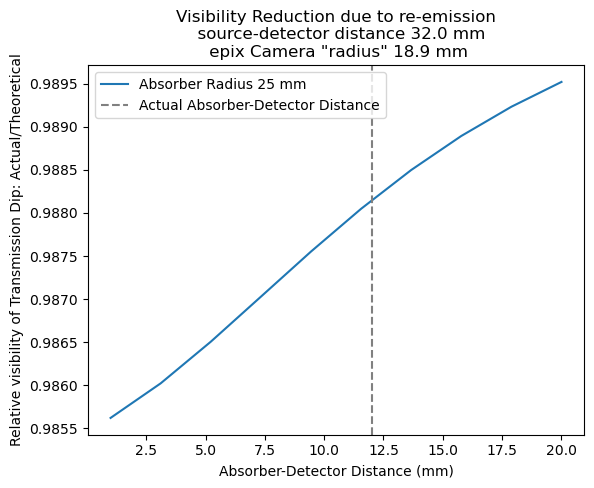

In [132]:
t = t_A2
moss = moss_A2
absorber = absorberA2
source = sourceFe

visibility_meas = 70/1200
visibility_theory_max = (t.max()-t.min())/t.max()

SNR = 1
vis_reduction = 1-0.5/(SNR)
visibility_theory = (t.max()-t.min())/t.max()*vis_reduction

d_sd = 32e-3
d_sa = 22e-3
d_ad = d_sd - d_sa
r_a = 25.4e-3
r_d = 35e-3/2

def compute_solid_angle(r, d):
    return 2*np.pi*(1-d/np.sqrt(r**2 + d**2))

s_d_solid_angle = compute_solid_angle(r_d, d_sd)
s_a_solid_angle = compute_solid_angle(r_a, d_sa)
a_d_solid_angle = compute_solid_angle(r_d, d_ad)
solid_angle_ratio =  s_a_solid_angle/s_d_solid_angle
reemitted_fraction = visibility_theory_max*1/(absorber.alpha+1)
visibility_actual_from_reemitted = visibility_theory*(1-reemitted_fraction*solid_angle_ratio*a_d_solid_angle/(4*np.pi)
)

print(f"Measured visibility: {visibility_meas:.3f}")
print(f"Theoretical max visibility: {visibility_theory_max:.3f}")
print(f"Theoretical visibility with SNR={SNR}: {visibility_theory:.3f}")
print(f"Actual visibility from reemitted: {visibility_actual_from_reemitted:.3f}")
print(f"Solid angle ratio: {solid_angle_ratio:.3f}")
print(f"Absorber relative solid angle: {a_d_solid_angle/(4*np.pi):.3f}")
print(f"Reemitted detected fraction: {reemitted_fraction:.3f}")


vlist = []
dlist = np.linspace(1e-3,20e-3,10)
ralist = [25.4e-3]

for r_a in ralist:
    vlist = []

    for d_ad in dlist:
        #d_sd = 100e-3
        d_sa = d_sd - d_ad
        #r_a = 20e-3
        r_d = np.sqrt((35e-3*32e-3)/np.pi)


        s_d_solid_angle = compute_solid_angle(r_d, d_sd)
        s_a_solid_angle = compute_solid_angle(r_a, d_sa)
        a_d_solid_angle = compute_solid_angle(r_d, d_ad)
        solid_angle_ratio =  s_a_solid_angle/s_d_solid_angle
        reemitted_fraction = visibility_theory_max*1/(absorber.alpha+1)
        visibility_actual_from_reemitted = visibility_theory*(1-reemitted_fraction*solid_angle_ratio*a_d_solid_angle/(4*np.pi)
        )

        vlist.append(visibility_actual_from_reemitted)
    plt.plot(dlist*1e3, np.array(vlist)/visibility_theory, label=f'Absorber Radius {r_a*1e3:.0f} mm')
    plt.axvline(x=d_sa*1e3, color='gray', linestyle='--', label='Actual Absorber-Detector Distance')
    plt.xlabel('Absorber-Detector Distance (mm)')
    plt.ylabel('Relative visibility of Transmission Dip: Actual/Theoretical')
    plt.title(f'Visibility Reduction due to re-emission\n  source-detector distance {d_sd*1e3:.1f} mm\n epix Camera "radius" {r_d*1e3:.1f} mm')

plt.legend()    

